In [35]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# will be used to load MATLAB mat datafile format
from scipy.io import loadmat

In [36]:
# parameters: 
# m = size of the dataset
# n2 = number of neurons in the second layer
# alpha = learning rate for the gradient descent
# Niter = number of iterations if the gradient descent

n2 = 25
alpha = 0.3
Niter = 4000
lambda_reg = 0.5

In [37]:
#  training data stored in arrays X, y
data = loadmat('ex3data1.mat')
X, y_data = data['X'], data['y'].ravel()

# set the zero digit to 0, rather than its mapped 10 in this dataset
y_data[y_data == 10] = 0

# Number of training examples
m = y_data.size

In [38]:
# function used to visualize the data
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Displays 2D data stored in X in a nice grid.
    """
    # Compute rows, cols
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promote to a 2 dimensional array
    else:
        raise IndexError('Input X should be 1 or 2 dimensional.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    # Compute number of items to display
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(example_width, example_width, order='F'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')


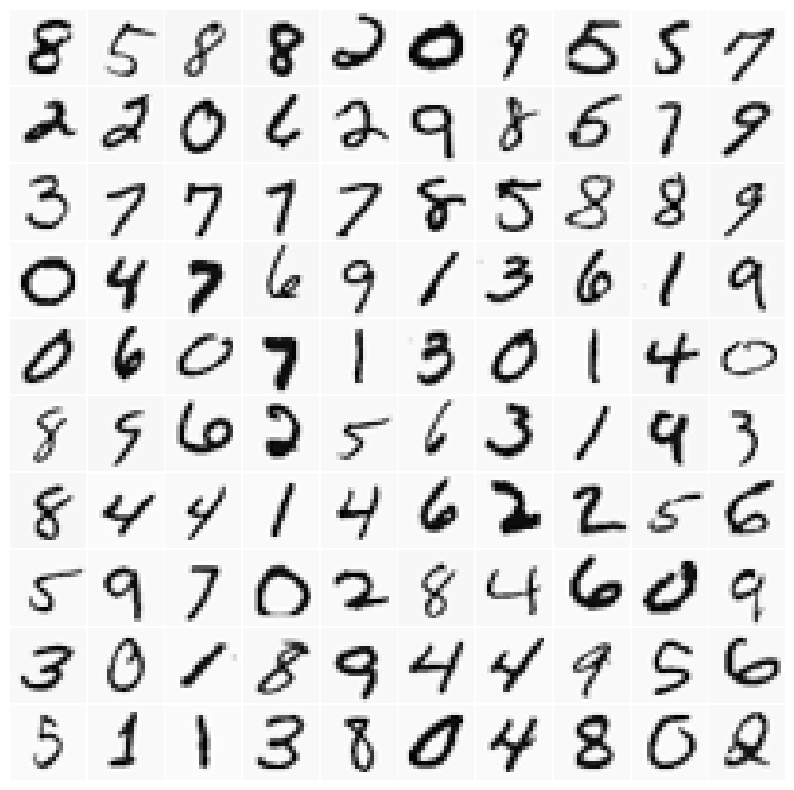

In [39]:
# Randomly select 100 images and display them
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)

In [40]:
# make sure the images are stored in the column of X
X=X.T
print(X.shape)

(400, 5000)


In [41]:
# you must one hot encode the vector y_data and store in the matrix y
# Initialisation de la matrice y avec des zéros (10 classes x 5000 images)
y = np.zeros((10, m))

# Indexation avancée : on place un 1.0 aux coordonnées (label de l'image, index de l'image)
y[y_data, np.arange(m)] = 1.0

print("Nouvelle dimension de y :", y.shape)

Nouvelle dimension de y : (10, 5000)


In [42]:
# activation function
def sigma(z):
    return 1/(1+np.exp(-z))

In [43]:
# derivative of the activation function
def sigma_prim(z):
    return np.exp(-z)/((1+np.exp(-z))**2)

In [44]:
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [45]:
def compute_cost_reg(a3, y, m, W2, W3, lambda_reg):
    cost = (-1/m) * np.sum(y*np.log(a3))

    regularization = (lambda_reg/(2*m)) * (np.sum(np.square(W2)) + np.sum(np.square(W3)))
    return cost + regularization

In [46]:
def predict(a3):
    return np.argmax(a3, axis=0)

In [47]:
# random initialization of the parameters of the neural network

W2 = np.random.randn(n2,1)
b2 = np.random.randn(n2,1)

#avant
#W3 = np.random.randn(1,n2)
#b3 = np.random.randn(1)

W3 = np.random.randn(2, n2)
b3 = np.random.randn(2,1)

In [48]:
def compute_grad_reg(x, y, W2, W3, b2, b3, m, lambda_reg):
    A1 = x

    Z2 = W2@A1 + b2
    A2 = sigma(Z2)

    Z3 = W3@A2 + b3
    A3 = softmax(Z3)

    delta_3 = A3 - y
    delta_2 = (np.transpose(W3)@delta_3)*sigma_prim(Z2)

    dC_W2 = (1/m)*delta_2@np.transpose(A1) + (lambda_reg/m) * W2
    dC_W3 = (1/m)*delta_3@np.transpose(A2) + (lambda_reg/m) * W3
    
    dC_b2 = (1/m) * np.sum(delta_2, axis=1).reshape((W2.shape[0], 1))
    dC_b3 = (1/m) * np.sum(delta_3, axis=1).reshape((W3.shape[0], 1))
    
    return dC_W2, dC_W3, dC_b2, dC_b3

In [49]:
# Prediction of the model
def model_predict(X,W2,W3,b2,b3):
    
    A1 = X

    Z2 = W2@A1 + b2
    A2 = sigma(Z2)

    Z3 = W3@A2 + b3
    A3 = softmax(Z3)
    
    return A3

In [50]:
# 1. Initialisation avec les nouvelles dimensions
# Entrées = 400 pixels, n2 = 25 (d'après ta cellule 2), Sorties = 10 classes
W2 = np.random.randn(n2, 400)
b2 = np.random.randn(n2, 1)

W3 = np.random.randn(10, n2)
b3 = np.random.randn(10, 1)

# 2. Boucle d'apprentissage
Cost = np.zeros(Niter)

for j in range(Niter):
    y_pred = model_predict(X, W2, W3, b2, b3)
    Cost[j] = compute_cost_reg(y_pred, y, m, W2, W3, lambda_reg)
        
    dC_dW2, dC_dW3, dC_db2, dC_db3 = compute_grad_reg(X, y, W2, W3, b2, b3, m, lambda_reg)

    W2 = W2 - alpha * dC_dW2
    W3 = W3 - alpha * dC_dW3
    b2 = b2 - alpha * dC_db2
    b3 = b3 - alpha * dC_db3

# 3. Évaluation de la précision (Accuracy)
y_pred = model_predict(X, W2, W3, b2, b3)
predictions = np.argmax(y_pred, axis=0)

# Comme on a déjà y_data qui contient les vrais labels de 0 à 9, on l'utilise directement
print("Accuracy sur le set d'entraînement :", 100 * np.mean(predictions == y_data), "%")

Accuracy sur le set d'entraînement : 93.2 %


In [51]:
from sklearn.utils import shuffle

# 1. Brassage des données (Shuffling)
X_shuffled, Y_shuffled = shuffle(X.T, y.T, random_state=42)
X_shuffled = X_shuffled.T
Y_shuffled = Y_shuffled.T

# 2. Séparation Train / Validation / Test (Question 3)
m_train = 3000
m_val = 1000
m_test = 1000

X_train = X_shuffled[:, :m_train]
Y_train = Y_shuffled[:, :m_train]

X_val = X_shuffled[:, m_train : m_train + m_val]
Y_val = Y_shuffled[:, m_train : m_train + m_val]

X_test = X_shuffled[:, m_train + m_val :]
Y_test = Y_shuffled[:, m_train + m_val :]

print("Taille X_train :", X_train.shape)
print("Taille X_val   :", X_val.shape)
print("Taille X_test  :", X_test.shape)
print("-" * 30)

# 3. Paramètres de la grille de recherche
n2_values = [10, 20, 30]
Niter_values = [1500, 3000, 4500]

# Variables pour suivre le meilleur modèle
best_val_acc = 0.0
best_params = {}
best_weights = {}

print(f"{'n2':<5} | {'Niter':<6} | {'Alpha':<5} | {'Lambda':<6} | {'Validation Accuracy':<15}")
print("-" * 55)

# 4. Double boucle de recherche (Grid Search)
for n2_test in n2_values:
    for Niter_test in Niter_values:
        
        # Initialisation aléatoire spécifique aux dimensions de n2_test
        W2_loop = np.random.randn(n2_test, 400)
        b2_loop = np.random.randn(n2_test, 1)
        W3_loop = np.random.randn(10, n2_test)
        b3_loop = np.random.randn(10, 1)
        
        # Boucle d'apprentissage sur le Train Set (3000 images)
        for j in range(Niter_test):
            dC_dW2, dC_dW3, dC_db2, dC_db3 = compute_grad_reg(
                X_train, Y_train, W2_loop, W3_loop, b2_loop, b3_loop, m_train, lambda_reg
            )

            W2_loop -= alpha * dC_dW2
            W3_loop -= alpha * dC_dW3
            b2_loop -= alpha * dC_db2
            b3_loop -= alpha * dC_db3
            
        # Évaluation sur le Validation Set (1000 images)
        pred_val = model_predict(X_val, W2_loop, W3_loop, b2_loop, b3_loop)
        labels_val = np.argmax(pred_val, axis=0)
        vrais_labels_val = np.argmax(Y_val, axis=0)
        acc_val = 100 * np.mean(labels_val == vrais_labels_val)
        
        print(f"{n2_test:<5} | {Niter_test:<6} | {alpha:<5} | {lambda_reg:<6} | {acc_val:.2f} %")
        
        # Sauvegarde de la meilleure configuration
        if acc_val > best_val_acc:
            best_val_acc = acc_val
            best_params = {'n2': n2_test, 'Niter': Niter_test}
            best_weights = {'W2': W2_loop, 'W3': W3_loop, 'b2': b2_loop, 'b3': b3_loop}

print("-" * 55)
print(f"Meilleurs hyperparamètres trouvés : n2 = {best_params['n2']}, Niter = {best_params['Niter']} (Accuracy Val = {best_val_acc:.2f} %)")
print("-" * 55)

# 5. Évaluation finale avec les MEILLEURS poids entraînés
# Accuracy sur l'entraînement (3000 images)
pred_train = model_predict(X_train, best_weights['W2'], best_weights['W3'], best_weights['b2'], best_weights['b3'])
labels_train = np.argmax(pred_train, axis=0)
vrais_labels_train = np.argmax(Y_train, axis=0)
acc_train = 100 * np.mean(labels_train == vrais_labels_train)
print(f"Accuracy sur l'entraînement (3000 images) : {acc_train:.2f} %")

# Accuracy sur le test final (1000 images inédites)
pred_test = model_predict(X_test, best_weights['W2'], best_weights['W3'], best_weights['b2'], best_weights['b3'])
labels_test = np.argmax(pred_test, axis=0)
vrais_labels_test = np.argmax(Y_test, axis=0)
acc_test = 100 * np.mean(labels_test == vrais_labels_test)
print(f"Accuracy sur le test (1000 images inédites) : {acc_test:.2f} %")

Taille X_train : (400, 3000)
Taille X_val   : (400, 1000)
Taille X_test  : (400, 1000)
------------------------------
n2    | Niter  | Alpha | Lambda | Validation Accuracy
-------------------------------------------------------
10    | 1500   | 0.3   | 0.5    | 83.40 %
10    | 3000   | 0.3   | 0.5    | 86.70 %
10    | 4500   | 0.3   | 0.5    | 87.10 %
20    | 1500   | 0.3   | 0.5    | 85.90 %
20    | 3000   | 0.3   | 0.5    | 87.60 %
20    | 4500   | 0.3   | 0.5    | 89.20 %
30    | 1500   | 0.3   | 0.5    | 87.90 %
30    | 3000   | 0.3   | 0.5    | 89.90 %
30    | 4500   | 0.3   | 0.5    | 90.80 %
-------------------------------------------------------
Meilleurs hyperparamètres trouvés : n2 = 30, Niter = 4500 (Accuracy Val = 90.80 %)
-------------------------------------------------------
Accuracy sur l'entraînement (3000 images) : 97.27 %
Accuracy sur le test (1000 images inédites) : 90.70 %
